# RaBitQ SAQ-Fair Evaluation Plots

Plots for RaBitQ-Library results computed on the exact SAQ-prepared base/query vectors and IVF partition.

Input CSVs: `/mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/*_RaBitQ_adc_vs_exact_eval.csv`

Output figures: `/mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2`

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 34,
    "axes.labelsize": 34,
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
    "legend.fontsize": 18,
})
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

PROJECT_ROOT = Path("/home/cpanourg/projects/2-hdvc")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = Path("/mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair")
FIGURES_DIR = DATA_DIR / "figures2"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASETS_TO_PLOT = ["deep", "bigann", "gist", "msmarco", "openai"]
FIGURE_SAVE_FORMATS = ("pdf", "svg")
COLOR = "tab:blue"
MARKER = "o"


In [2]:
def save_figure(fig, output_dir: Path, stem: str):
    output_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for ext in FIGURE_SAVE_FORMATS:
        path = output_dir / f"{stem}.{ext}"
        fig.savefig(path, bbox_inches="tight")
        saved.append(path)
    print("Saved " + " and ".join(str(p) for p in saved))


def style_axes(ax, grid_axis="y"):
    ax.grid(True, axis=grid_axis, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=28)


def set_sci_axes(ax):
    for axis in [ax.xaxis, ax.yaxis]:
        fmt = ScalarFormatter(useMathText=True)
        fmt.set_powerlimits((-2, 3))
        axis.set_major_formatter(fmt)


def set_integer_xticks(ax, values, max_ticks: int = 4):
    vals = sorted({int(round(float(v))) for v in values if pd.notna(v)})
    if not vals:
        return
    if len(vals) > max_ticks:
        idx = np.linspace(0, len(vals) - 1, max_ticks).round().astype(int)
        vals = [vals[i] for i in sorted(set(idx))]
    ax.set_xticks(vals)
    ax.set_xticklabels([str(v) for v in vals], rotation=0)


In [3]:
def load_rabitq_saqfair_data(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    csv_paths = sorted(data_dir.glob("*_RaBitQ_adc_vs_exact_eval.csv"))
    if not csv_paths:
        raise FileNotFoundError(f"No RaBitQ CSV files found in {data_dir}")

    frames = []
    for path in csv_paths:
        df = pd.read_csv(path)
        if "dataset" not in df.columns:
            df["dataset"] = path.name.split("_")[0]
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)
    numeric_cols = [
        "bits_per_vector", "nbits", "train_size", "adc_time_s", "rel_error_mean", "rel_error_std",
        "train_time_s", "encoding_time_s", "distance_table_time_s", "cdist_time_s",
        "nb_sample", "nq_sample", "dim", "nb", "nq", "n_subquantizers", "seed",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.sort_values(["dataset", "nbits"]).reset_index(drop=True)
    return df


raw_df = load_rabitq_saqfair_data()
print("Rows per dataset:")
display(raw_df.groupby("dataset").size())
raw_df[["dataset", "nbits", "bits_per_vector", "rel_error_mean", "rel_error_std", "encoding_time_s", "adc_time_s", "sample_mode"]]


Rows per dataset:


dataset
bigann     4
deep       4
gist       4
msmarco    4
openai     4
dtype: int64

,dataset,nbits,bits_per_vector,rel_error_mean,rel_error_std,encoding_time_s,adc_time_s,sample_mode
0,bigann,1,128,0.003418,0.020224,0.696218,0.768199,rabitqlib_topk=100_nprobe=200
1,bigann,2,256,0.000510,0.005114,1.215416,0.827521,rabitqlib_topk=100_nprobe=200
2,bigann,4,512,0.000000,0.000000,1.561864,0.857369,rabitqlib_topk=100_nprobe=200
3,bigann,8,1024,0.000000,0.000000,3.427325,0.732465,rabitqlib_topk=100_nprobe=200
4,deep,1,96,0.008089,0.041146,0.490721,0.518402,rabitqlib_topk=100_nprobe=200
5,deep,2,192,0.000099,0.001018,0.711657,0.524514,rabitqlib_topk=100_nprobe=200
6,deep,4,384,0.000221,0.002254,1.259953,0.563210,rabitqlib_topk=100_nprobe=200
7,deep,8,768,0.000000,0.000000,3.226711,0.590598,rabitqlib_topk=100_nprobe=200
8,gist,1,960,0.000060,0.000686,3.565277,5.160932,rabitqlib_topk=100_nprobe=200
9,gist,2,1920,0.000000,0.000000,7.179676,5.272688,rabitqlib_topk=100_nprobe=200


In [4]:
def _hp_label(row):
    mode = row.get("sample_mode", "")
    if pd.isna(mode) or not str(mode):
        return "config"
    return str(mode).replace("rabitqlib_", "")


def plot_metric_vs_param(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    x_label: str,
    y_label: str,
    output_stem: str,
    datasets=DATASETS_TO_PLOT,
    output_dir: Path = FIGURES_DIR,
):
    for dataset in datasets:
        sub = df[df["dataset"].eq(dataset)].dropna(subset=[x_col, y_col]).copy()
        if sub.empty:
            print(f"Skipping {dataset}: no rows")
            continue
        sub["hp_config"] = sub.apply(_hp_label, axis=1)
        fig, ax = plt.subplots()
        for idx, (hp_config, curve) in enumerate(sub.groupby("hp_config", sort=True)):
            curve = curve.sort_values(x_col)
            ax.plot(
                curve[x_col], curve[y_col],
                marker=MARKER, linestyle="-", color=COLOR, markersize=14,
                linewidth=2.5, markeredgewidth=1.8, markeredgecolor="black",
                label=hp_config,
            )
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        style_axes(ax, grid_axis="y")
        set_sci_axes(ax)
        if x_col in ("bits_per_vector", "nbits"):
            max_xticks = 3 if x_col == "bits_per_vector" else 4
            set_integer_xticks(ax, sub[x_col].dropna().unique(), max_ticks=max_xticks)
        if sub["hp_config"].nunique() > 1:
            ax.legend(frameon=True, fontsize=13, loc="best")
        plt.tight_layout()
        save_figure(fig, output_dir, f"{output_stem}_rabitq_saqfair_{dataset}")
        plt.show()
        plt.close(fig)


## Relative Error

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_bits_per_vector_rabitq_saqfair_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_bits_per_vector_rabitq_saqfair_deep.svg


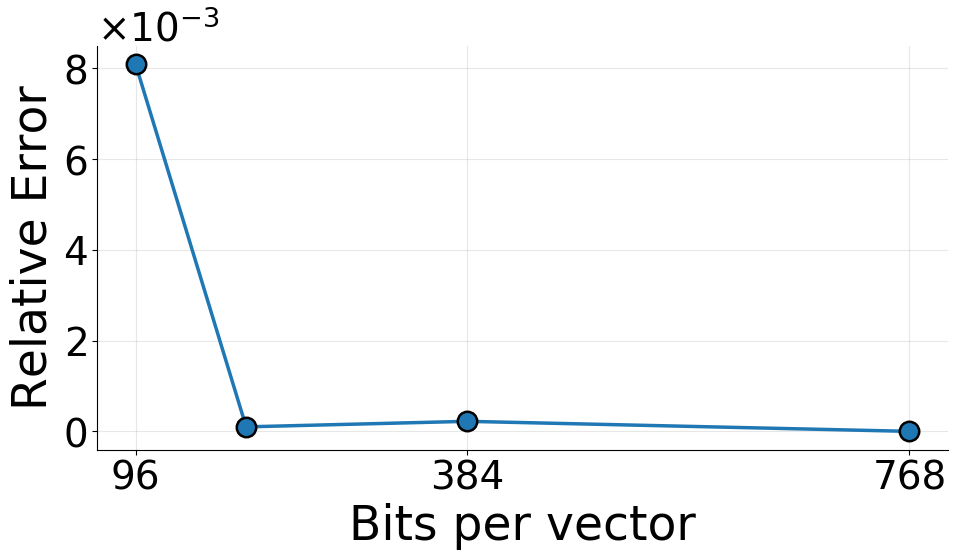

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_bits_per_vector_rabitq_saqfair_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_bits_per_vector_rabitq_saqfair_bigann.svg


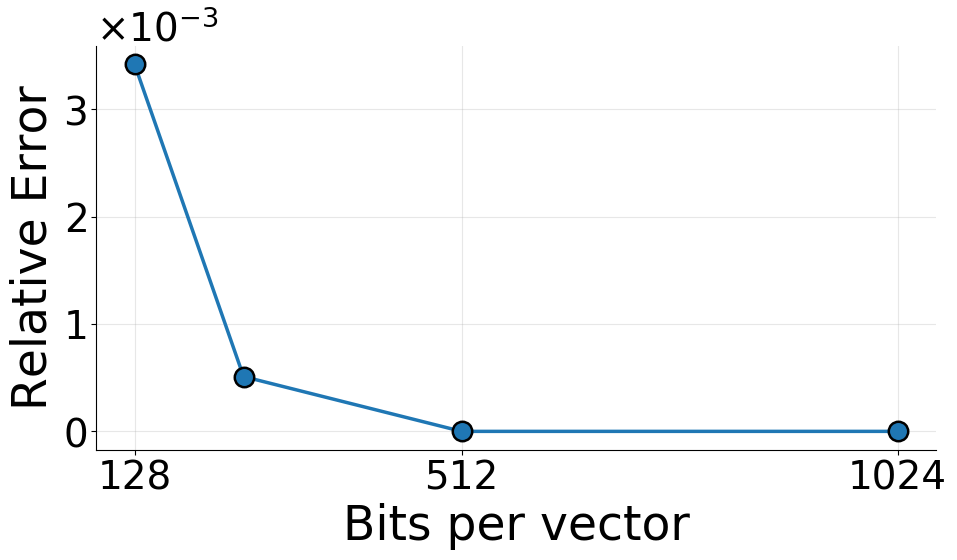

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_bits_per_vector_rabitq_saqfair_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_bits_per_vector_rabitq_saqfair_gist.svg


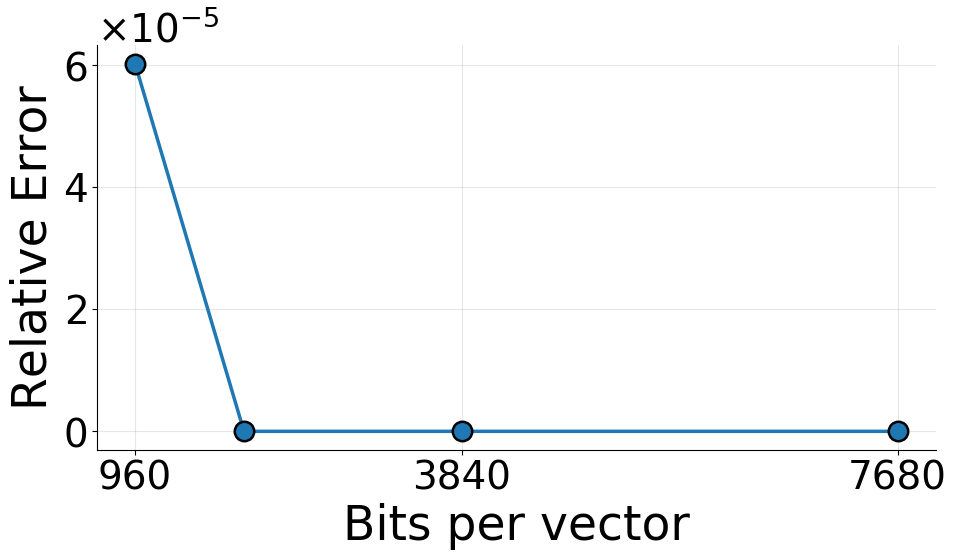

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_bits_per_vector_rabitq_saqfair_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_bits_per_vector_rabitq_saqfair_msmarco.svg


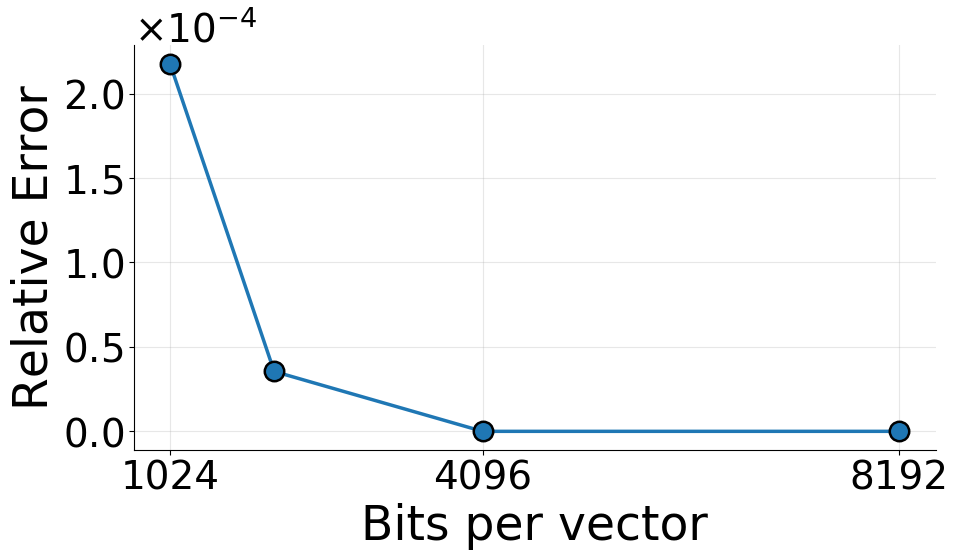

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_bits_per_vector_rabitq_saqfair_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_bits_per_vector_rabitq_saqfair_openai.svg


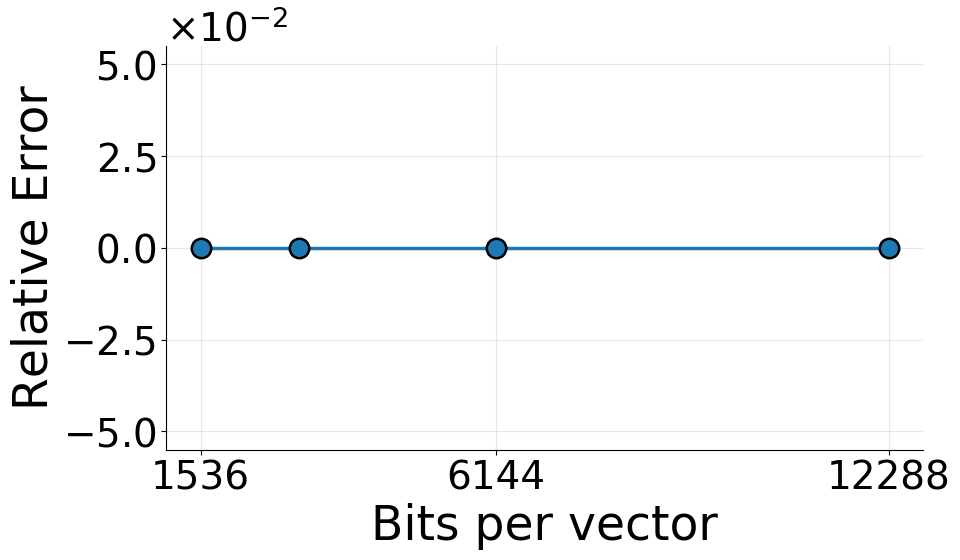

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_nbits_rabitq_saqfair_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_nbits_rabitq_saqfair_deep.svg


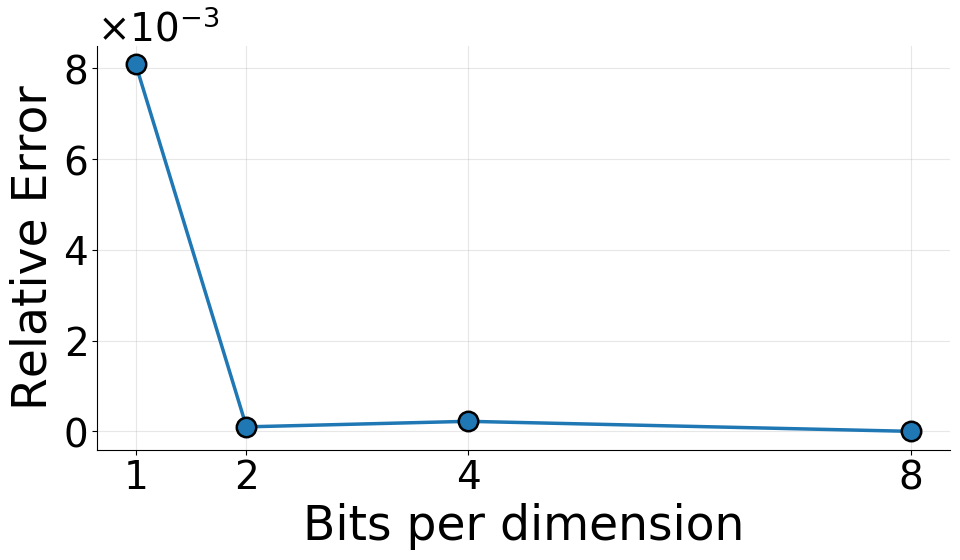

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_nbits_rabitq_saqfair_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_nbits_rabitq_saqfair_bigann.svg


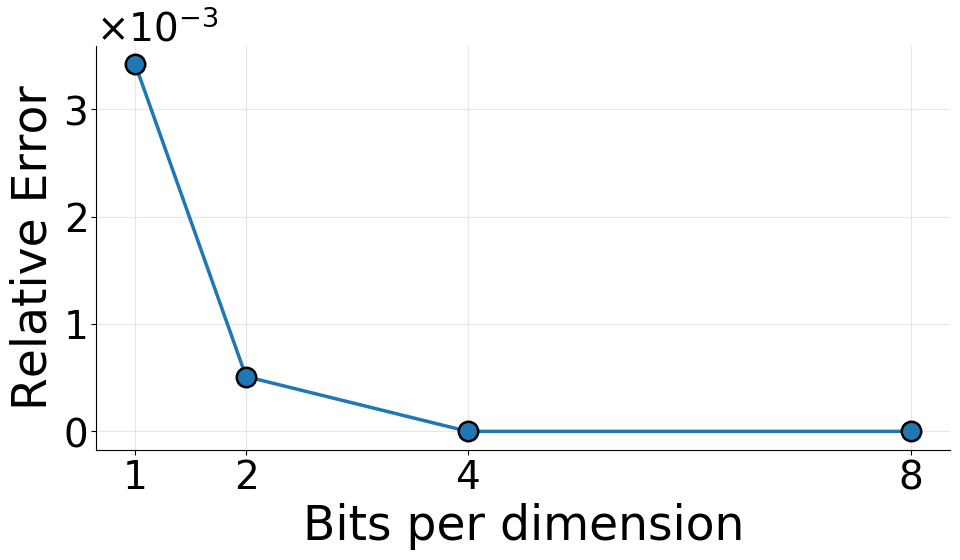

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_nbits_rabitq_saqfair_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_nbits_rabitq_saqfair_gist.svg


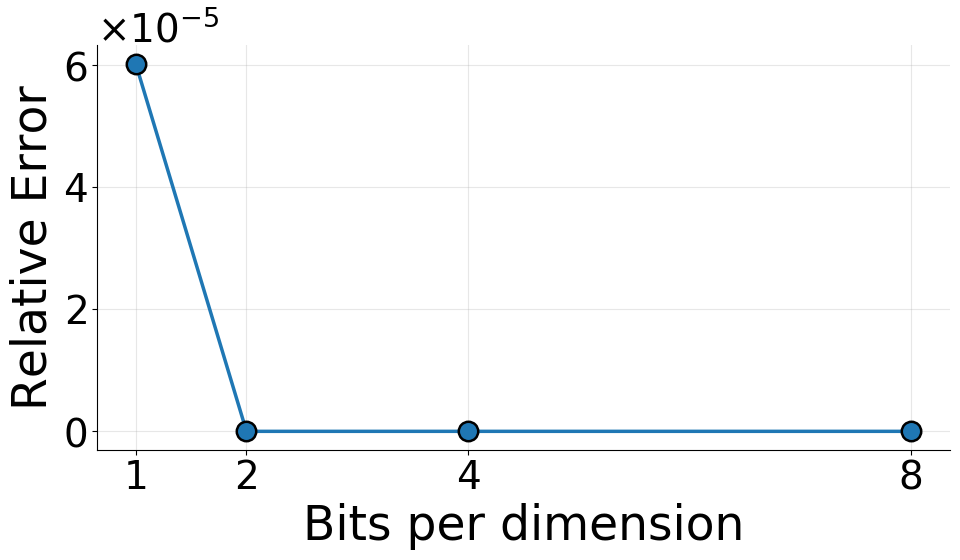

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_nbits_rabitq_saqfair_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_nbits_rabitq_saqfair_msmarco.svg


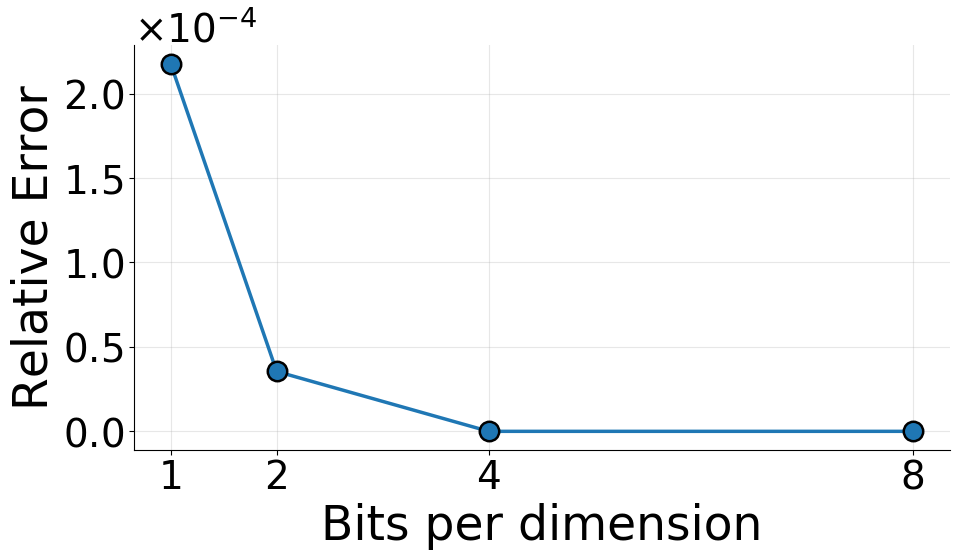

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_nbits_rabitq_saqfair_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/relerr_vs_nbits_rabitq_saqfair_openai.svg


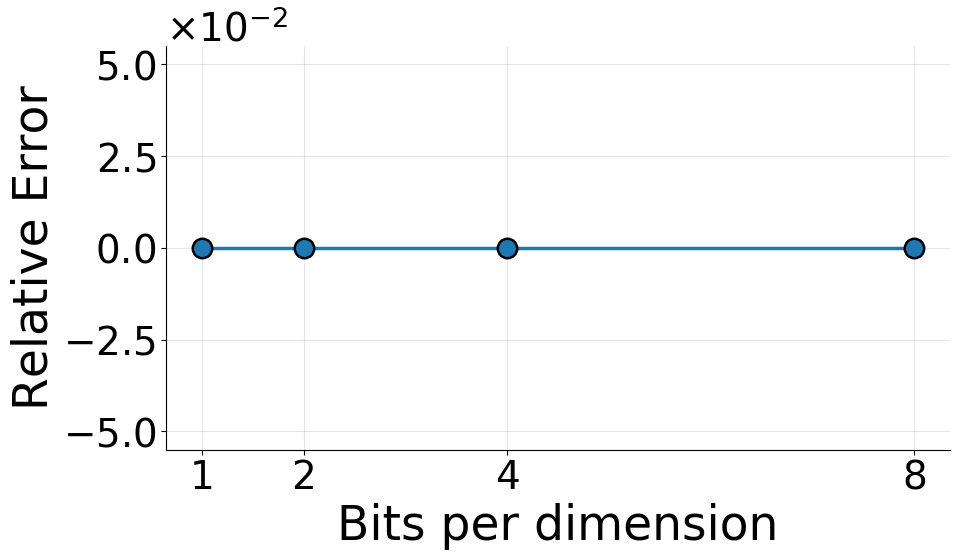

In [5]:
plot_metric_vs_param(
    raw_df,
    x_col="bits_per_vector",
    y_col="rel_error_mean",
    x_label="Bits per vector",
    y_label="Relative Error",
    output_stem="relerr_vs_bits_per_vector",
)

plot_metric_vs_param(
    raw_df,
    x_col="nbits",
    y_col="rel_error_mean",
    x_label="Bits per dimension",
    y_label="Relative Error",
    output_stem="relerr_vs_nbits",
)


## Timing

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_bits_per_vector_rabitq_saqfair_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_bits_per_vector_rabitq_saqfair_deep.svg


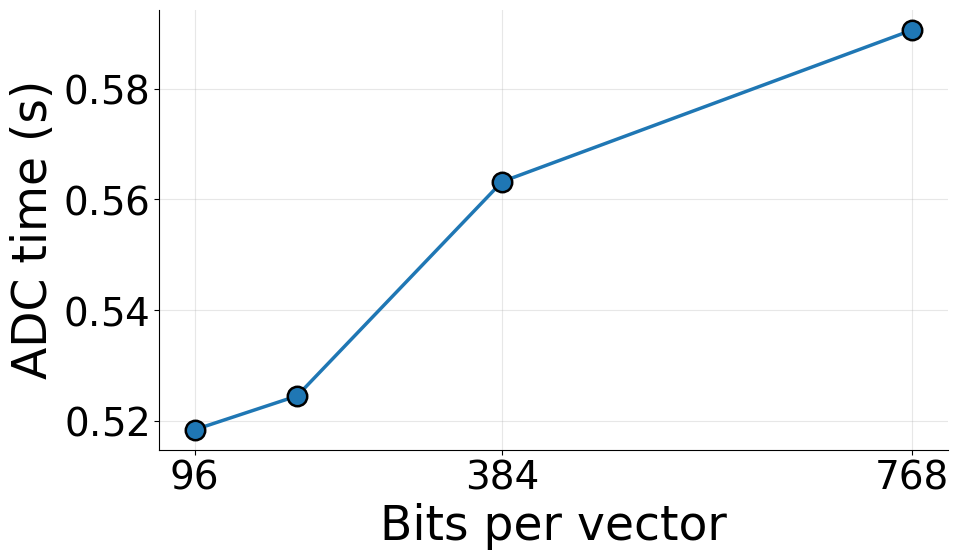

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_bits_per_vector_rabitq_saqfair_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_bits_per_vector_rabitq_saqfair_bigann.svg


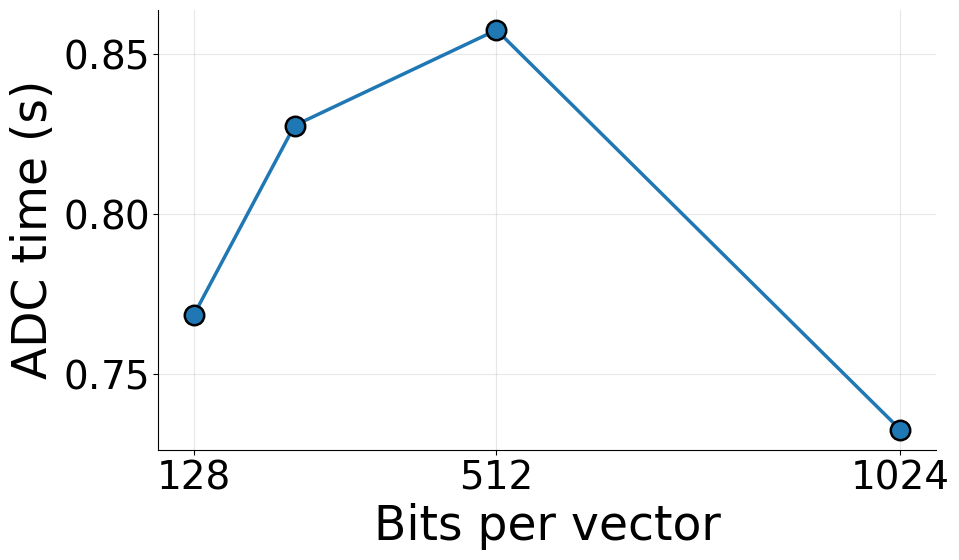

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_bits_per_vector_rabitq_saqfair_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_bits_per_vector_rabitq_saqfair_gist.svg


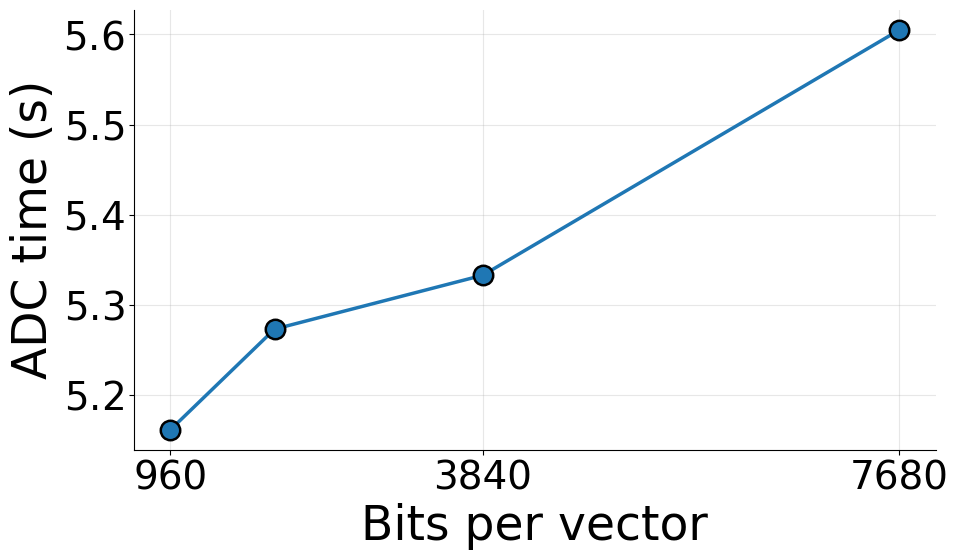

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_bits_per_vector_rabitq_saqfair_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_bits_per_vector_rabitq_saqfair_msmarco.svg


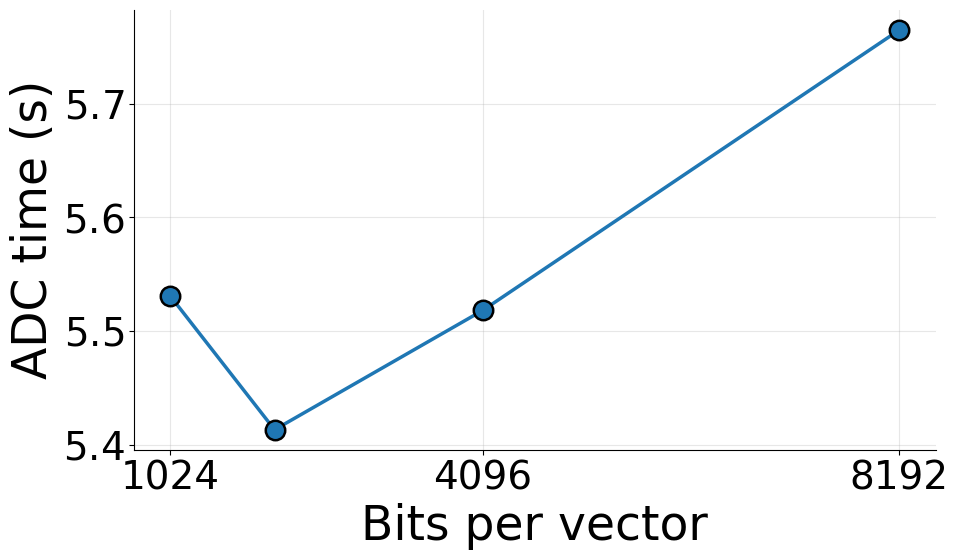

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_bits_per_vector_rabitq_saqfair_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_bits_per_vector_rabitq_saqfair_openai.svg


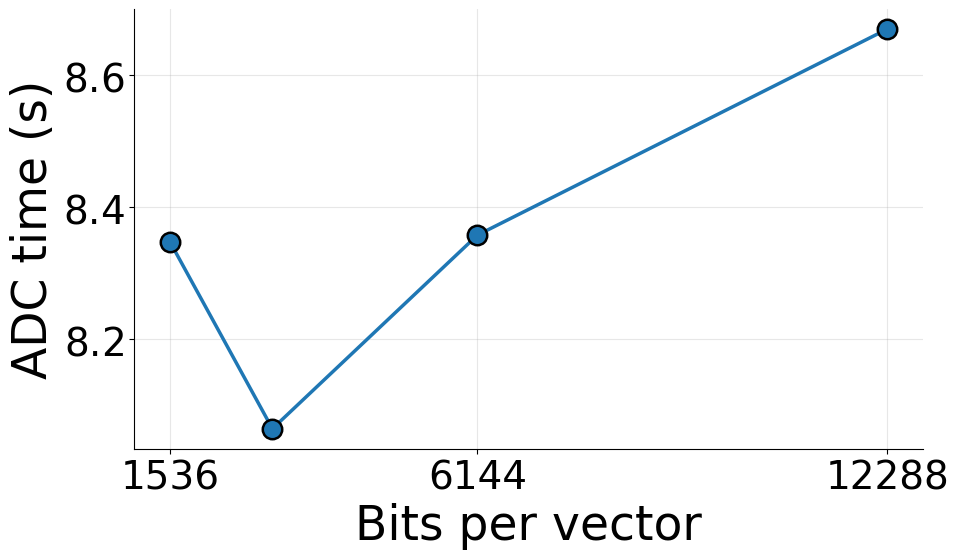

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_nbits_rabitq_saqfair_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_nbits_rabitq_saqfair_deep.svg


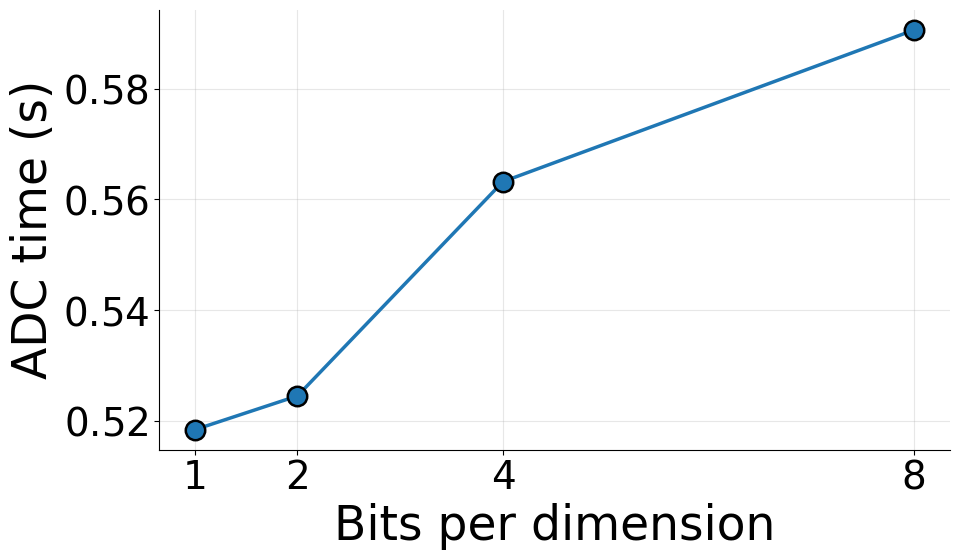

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_nbits_rabitq_saqfair_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_nbits_rabitq_saqfair_bigann.svg


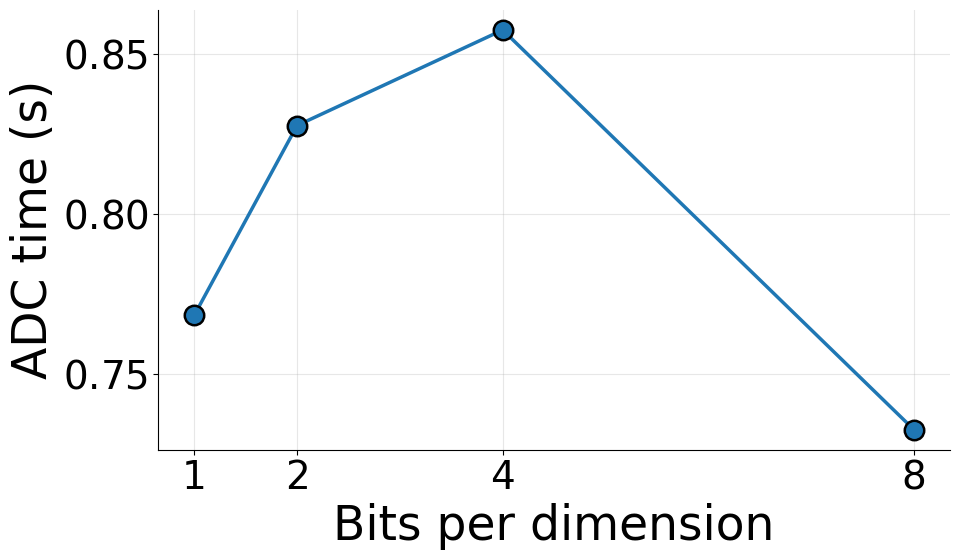

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_nbits_rabitq_saqfair_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_nbits_rabitq_saqfair_gist.svg


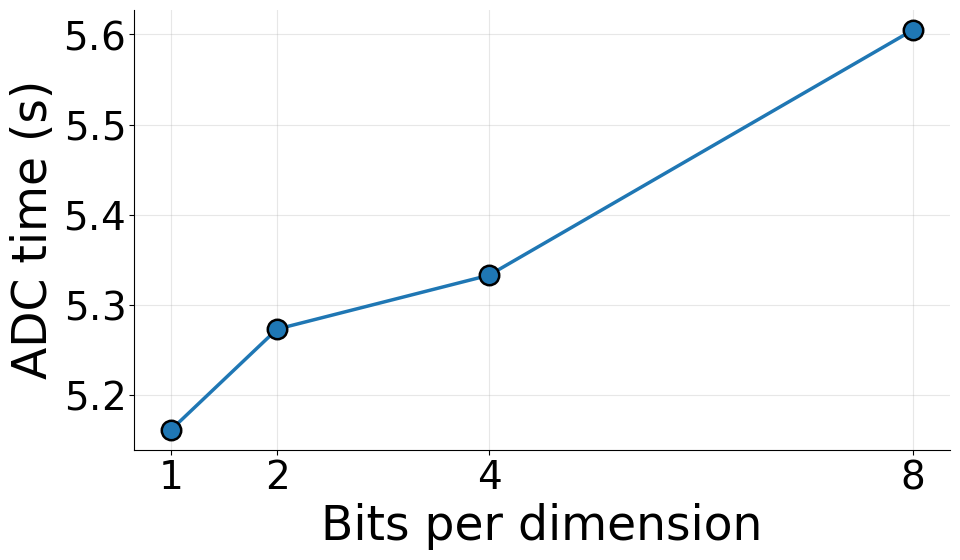

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_nbits_rabitq_saqfair_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_nbits_rabitq_saqfair_msmarco.svg


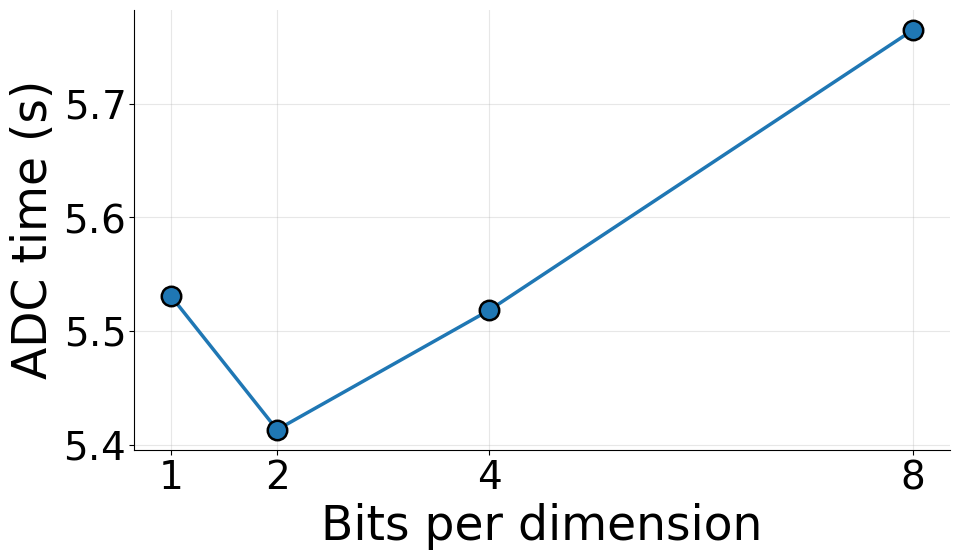

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_nbits_rabitq_saqfair_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/adc_time_vs_nbits_rabitq_saqfair_openai.svg


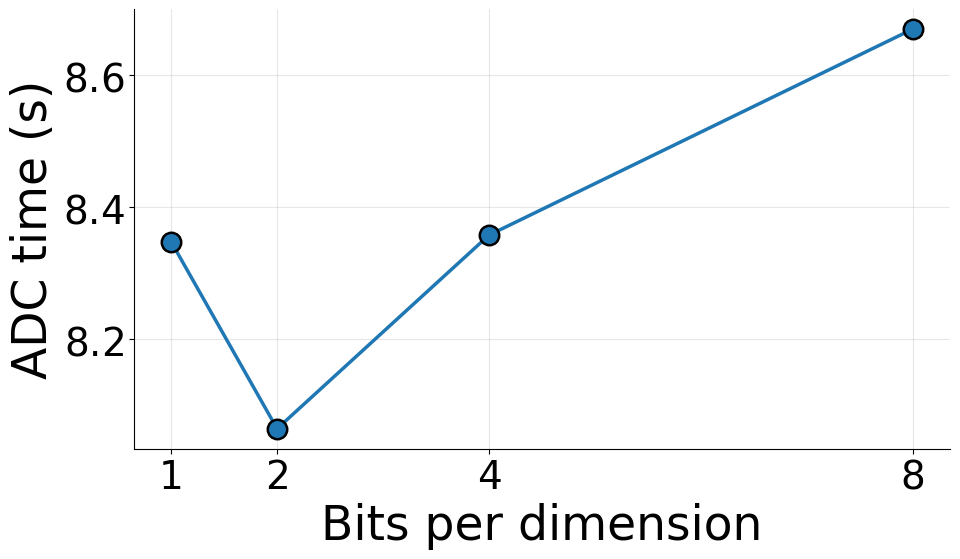

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_bits_per_vector_rabitq_saqfair_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_bits_per_vector_rabitq_saqfair_deep.svg


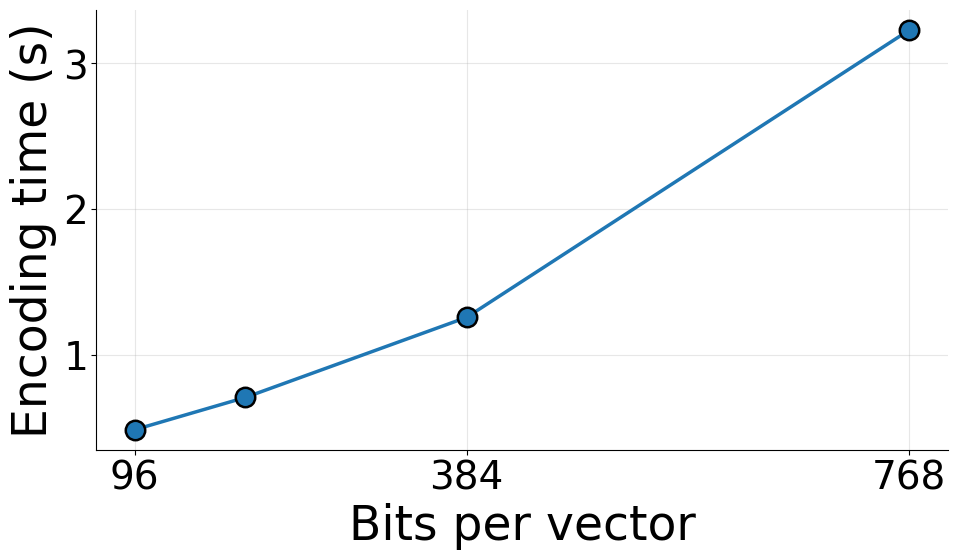

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_bits_per_vector_rabitq_saqfair_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_bits_per_vector_rabitq_saqfair_bigann.svg


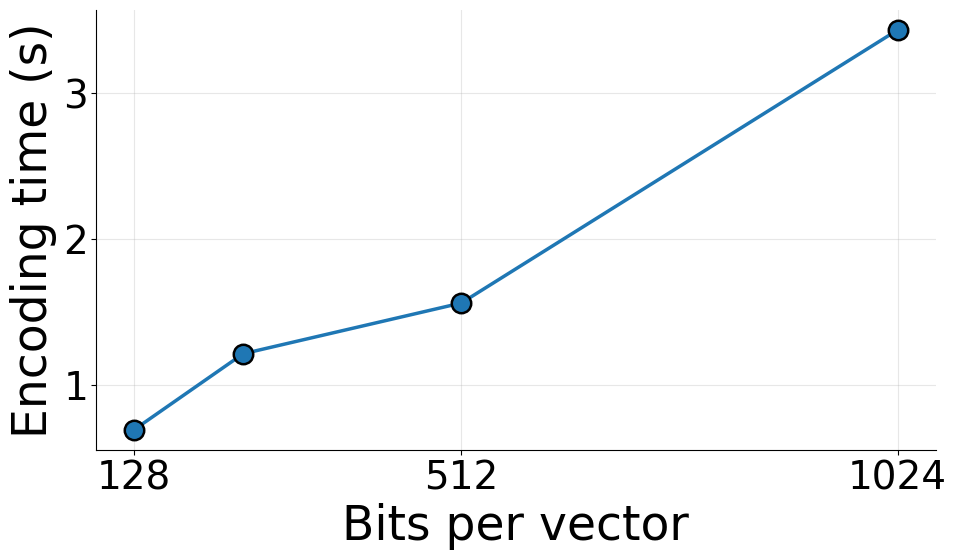

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_bits_per_vector_rabitq_saqfair_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_bits_per_vector_rabitq_saqfair_gist.svg


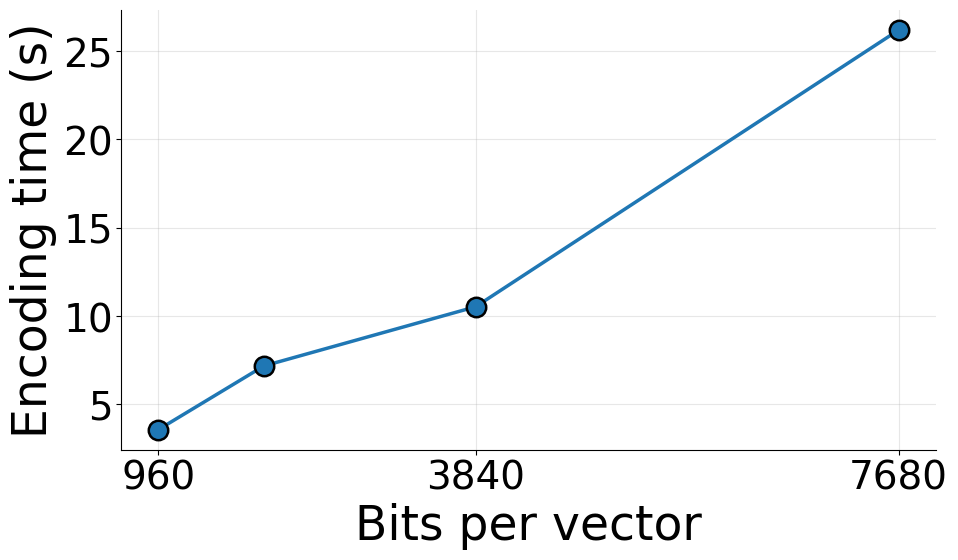

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_bits_per_vector_rabitq_saqfair_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_bits_per_vector_rabitq_saqfair_msmarco.svg


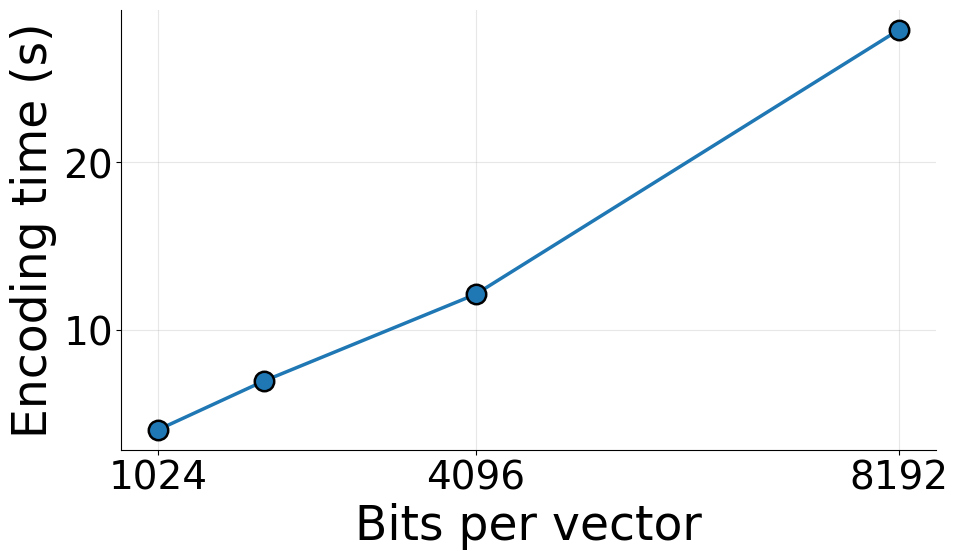

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_bits_per_vector_rabitq_saqfair_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_bits_per_vector_rabitq_saqfair_openai.svg


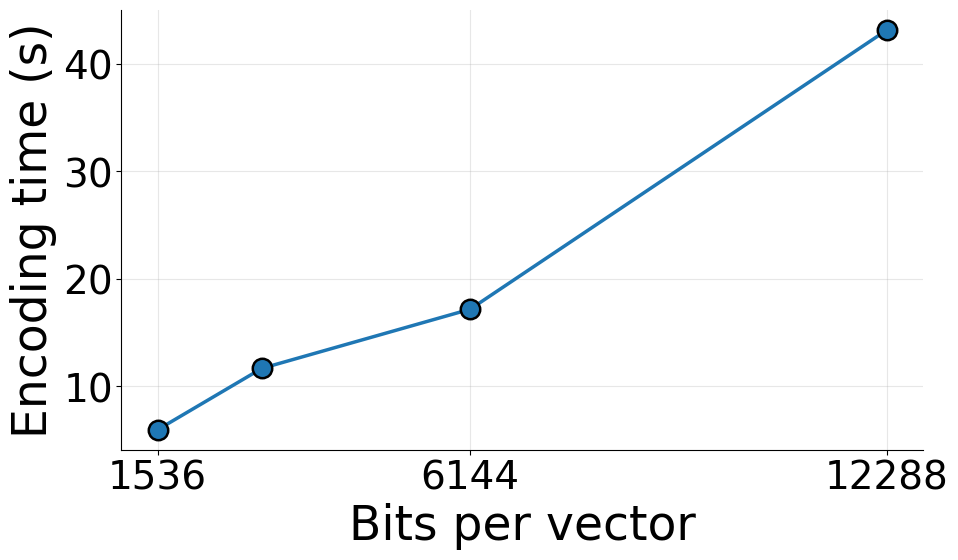

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_nbits_rabitq_saqfair_deep.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_nbits_rabitq_saqfair_deep.svg


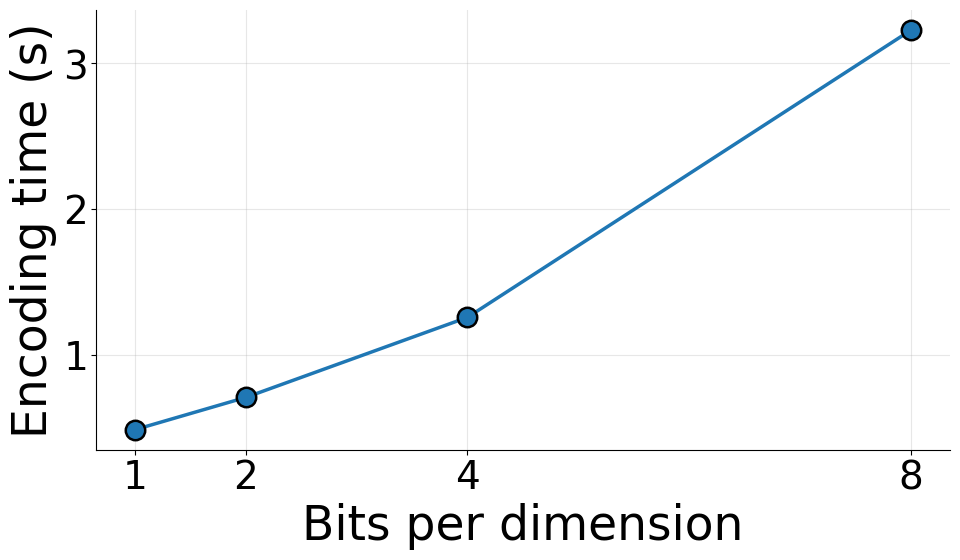

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_nbits_rabitq_saqfair_bigann.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_nbits_rabitq_saqfair_bigann.svg


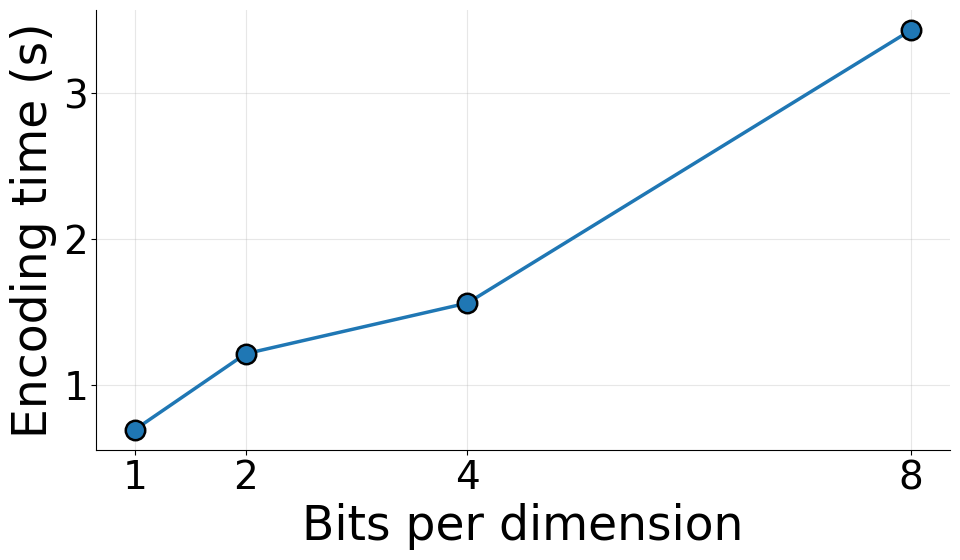

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_nbits_rabitq_saqfair_gist.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_nbits_rabitq_saqfair_gist.svg


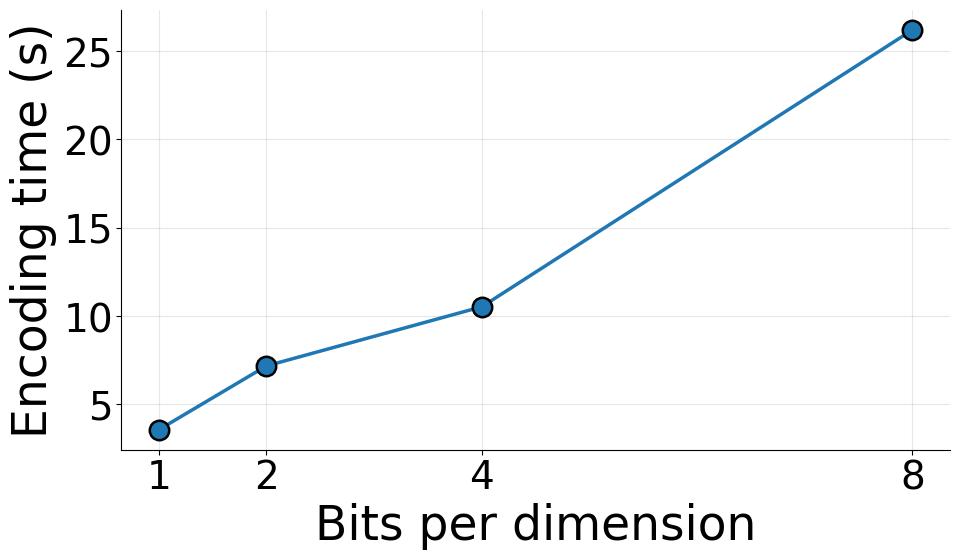

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_nbits_rabitq_saqfair_msmarco.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_nbits_rabitq_saqfair_msmarco.svg


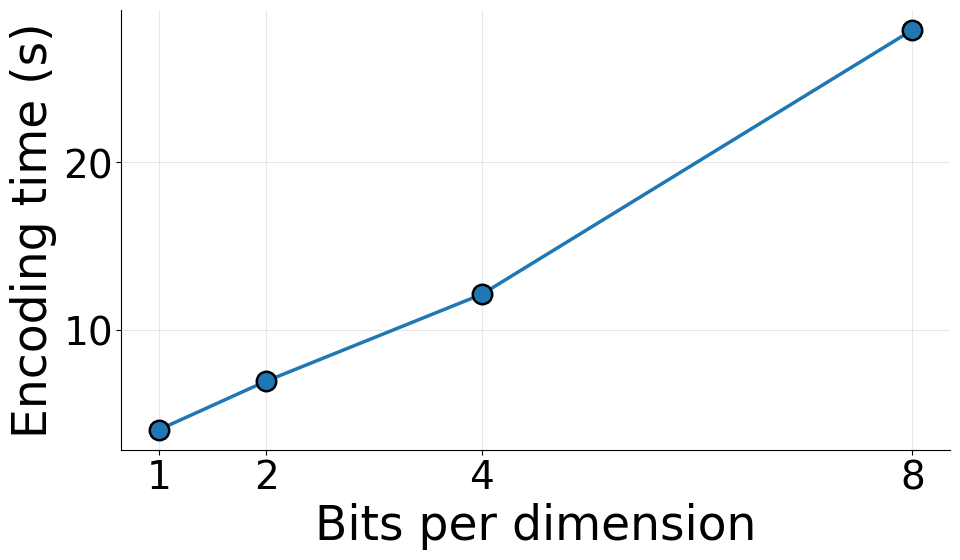

Saved /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_nbits_rabitq_saqfair_openai.pdf and /mnthdd/cpanourg/2-hdvc/results/urania_results/results/rabitq_saqfair/figures2/encoding_time_vs_nbits_rabitq_saqfair_openai.svg


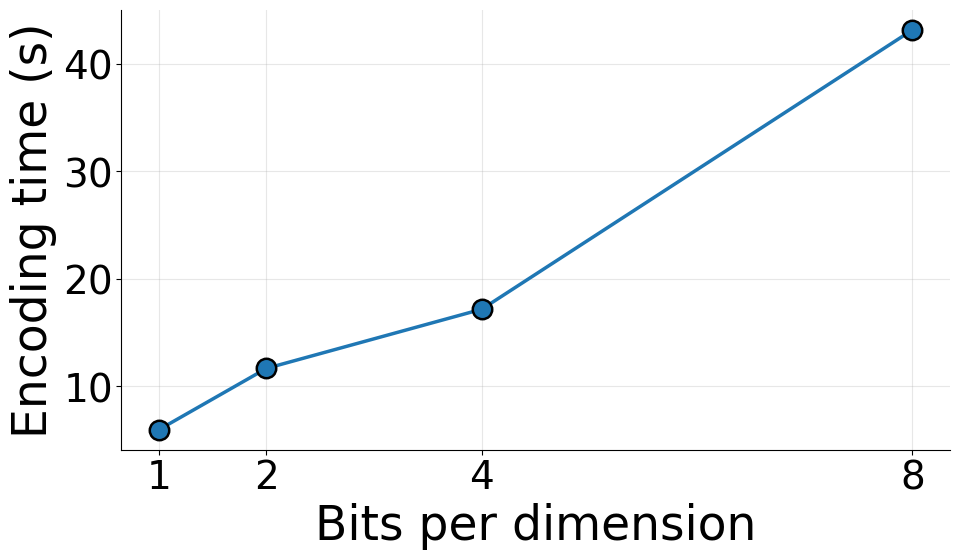

In [6]:
plot_metric_vs_param(
    raw_df,
    x_col="bits_per_vector",
    y_col="adc_time_s",
    x_label="Bits per vector",
    y_label="ADC time (s)",
    output_stem="adc_time_vs_bits_per_vector",
)

plot_metric_vs_param(
    raw_df,
    x_col="nbits",
    y_col="adc_time_s",
    x_label="Bits per dimension",
    y_label="ADC time (s)",
    output_stem="adc_time_vs_nbits",
)

plot_metric_vs_param(
    raw_df,
    x_col="bits_per_vector",
    y_col="encoding_time_s",
    x_label="Bits per vector",
    y_label="Encoding time (s)",
    output_stem="encoding_time_vs_bits_per_vector",
)

plot_metric_vs_param(
    raw_df,
    x_col="nbits",
    y_col="encoding_time_s",
    x_label="Bits per dimension",
    y_label="Encoding time (s)",
    output_stem="encoding_time_vs_nbits",
)
